In [41]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
df = pd.read_csv("../data/data.csv", sep=";")

# Clean column names
df.columns = df.columns.str.strip()

print(df.columns.tolist())

['Marital status', 'Application mode', 'Application order', 'Course', 'Daytime/evening attendance', 'Previous qualification', 'Previous qualification (grade)', 'Nacionality', "Mother's qualification", "Father's qualification", "Mother's occupation", "Father's occupation", 'Admission grade', 'Displaced', 'Educational special needs', 'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder', 'Age at enrollment', 'International', 'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)', 'Curricular units 1st sem (without evaluations)', 'Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)', 'Curricular units 2nd sem (without evaluations)', 'Unemployment rate', 'Inflation rate', 'GDP', 'Target']


In [9]:
df["Target"].value_counts()

Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

In [10]:
early_features = [
    "Marital status",
    "Application mode",
    "Application order",
    "Course",
    "Daytime/evening attendance",
    "Previous qualification",
    "Previous qualification (grade)",
    "Nacionality",
    "Mother's qualification",
    "Father's qualification",
    "Mother's occupation",
    "Father's occupation",
    "Admission grade",
    "Displaced",
    "Educational special needs",
    "Debtor",
    "Tuition fees up to date",
    "Gender",
    "Scholarship holder",
    "Age at enrollment",
    "International",
    "Unemployment rate",
    "Inflation rate",
    "GDP"
]

In [12]:
for col in early_features:
    if col not in df.columns:
        print("NOT FOUND:", col)

In [13]:
X = df[early_features]
y = df["Target"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (4424, 24)
y shape: (4424,)


In [14]:
X.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Unemployment rate,Inflation rate,GDP
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,1,1,0,20,0,10.8,1.4,1.74
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,0,0,1,0,19,0,13.9,-0.3,0.79
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,0,0,1,0,19,0,10.8,1.4,1.74
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,0,1,0,0,20,0,9.4,-0.8,-3.12
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,0,1,0,0,45,0,13.9,-0.3,0.79


In [15]:
y.head()

0     Dropout
1    Graduate
2     Dropout
3    Graduate
4    Graduate
Name: Target, dtype: object

In [16]:
X.dtypes

Marital status                      int64
Application mode                    int64
Application order                   int64
Course                              int64
Daytime/evening attendance          int64
Previous qualification              int64
Previous qualification (grade)    float64
Nacionality                         int64
Mother's qualification              int64
Father's qualification              int64
Mother's occupation                 int64
Father's occupation                 int64
Admission grade                   float64
Displaced                           int64
Educational special needs           int64
Debtor                              int64
Tuition fees up to date             int64
Gender                              int64
Scholarship holder                  int64
Age at enrollment                   int64
International                       int64
Unemployment rate                 float64
Inflation rate                    float64
GDP                               

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [18]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

In [19]:
numerical_features = [
    "Previous qualification (grade)",
    "Admission grade",
    "Age at enrollment",
    "Unemployment rate",
    "Inflation rate",
    "GDP"
]

In [20]:
categorical_features = [
    "Marital status",
    "Application mode",
    "Application order",
    "Course",
    "Daytime/evening attendance",
    "Previous qualification",
    "Nacionality",
    "Mother's qualification",
    "Father's qualification",
    "Mother's occupation",
    "Father's occupation",
    "Displaced",
    "Educational special needs",
    "Debtor",
    "Tuition fees up to date",
    "Gender",
    "Scholarship holder",
    "International"
]

In [21]:
numeric_transformer = StandardScaler()

In [22]:
categorical_transformer = OneHotEncoder(
    handle_unknown="ignore"
)

In [23]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [24]:
print(preprocessor)

ColumnTransformer(transformers=[('num', StandardScaler(),
                                 ['Previous qualification (grade)',
                                  'Admission grade', 'Age at enrollment',
                                  'Unemployment rate', 'Inflation rate',
                                  'GDP']),
                                ('cat', OneHotEncoder(handle_unknown='ignore'),
                                 ['Marital status', 'Application mode',
                                  'Application order', 'Course',
                                  'Daytime/evening attendance',
                                  'Previous qualification', 'Nacionality',
                                  "Mother's qualification",
                                  "Father's qualification",
                                  "Mother's occupation", "Father's occupation",
                                  'Displaced', 'Educational special needs',
                                  'Debtor', 'Tuition

In [25]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

In [26]:
logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=2000))
    ]
)

In [27]:
logistic_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Previous qualification '
                                                   '(grade)',
                                                   'Admission grade',
                                                   'Age at enrollment',
                                                   'Unemployment rate',
                                                   'Inflation rate', 'GDP']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Marital status',
                                                   'Application mode',
                                                   'Application order',
                                                   'Course',
                                                   'Daytime/evening attendance',
                                                   'Previous qualification',
                                                   'Nacionality',
                                                   "Mother's qualification",
                                                   "Father's qualification",
                                                   "Mother's occupation",
                                                   "Father's occupation",
                                                   'Displaced',
                                                   'Educational special needs',
                                                   'Debtor',
                                                   'Tuition fees up to date',
                                                   'Gender',
                                                   'Scholarship holder',
                                                   'International'])])),
                ('model', LogisticRegression(max_iter=2000))])

In [28]:
y_pred_lr = logistic_pipeline.predict(X_test)

In [29]:
print(y_pred_lr[:10])

['Graduate' 'Graduate' 'Graduate' 'Graduate' 'Graduate' 'Dropout'
 'Graduate' 'Graduate' 'Graduate' 'Graduate']


In [30]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [31]:
accuracy_lr = accuracy_score(y_test, y_pred_lr)

print("Logistic Regression Accuracy:", accuracy_lr)

Logistic Regression Accuracy: 0.6225988700564972


In [32]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

     Dropout       0.66      0.59      0.62       284
    Enrolled       0.26      0.12      0.16       159
    Graduate       0.65      0.82      0.73       442

    accuracy                           0.62       885
   macro avg       0.52      0.51      0.51       885
weighted avg       0.58      0.62      0.59       885



In [33]:
cm_lr = confusion_matrix(y_test, y_pred_lr)

print(cm_lr)

[[168  26  90]
 [ 38  19 102]
 [ 49  29 364]]


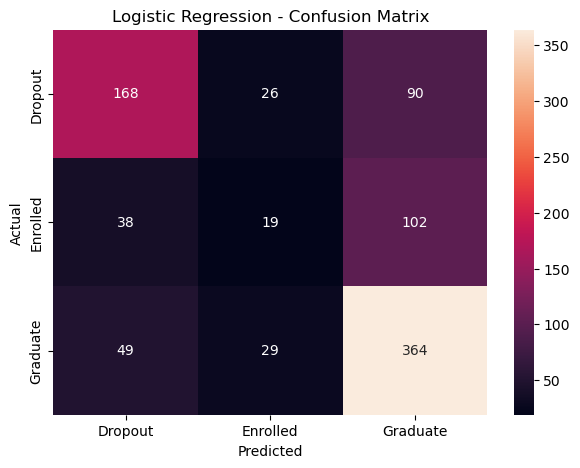

In [42]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    xticklabels=logistic_pipeline.classes_,
    yticklabels=logistic_pipeline.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression - Confusion Matrix")

plt.show()